In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
import sys
sys.path.append('..')
from ingestion.utils import get_engine
from dotenv import load_dotenv
import os
load_dotenv
server = os.getenv("DBSERVER")
database = os.getenv("DB_NAME")
engine = get_engine(server,database)
print("Conexión exitosa")

Conexión exitosa


In [5]:
fct_orders = pd.read_sql("SELECT * FROM dbt.fct_orders",engine)
dim_customers = pd.read_sql("SELECT * FROM dbt.dim_customers",engine)
dim_products = pd.read_sql("SELECT * FROM dbt.dim_products",engine)

print(f"Orders: {len(fct_orders):,} filas")
print(f"Customers: {len(dim_customers):,} filas")
print(f"Products: {len(dim_products):,} filas")

Orders: 539,391 filas
Customers: 4,371 filas
Products: 3,827 filas


In [7]:
total_revenue = fct_orders[fct_orders['is_cancelled']==0]['revenue'].sum()
total_orders = fct_orders[fct_orders['is_cancelled']==0]['invoice_number'].nunique()
total_customers = fct_orders['customer_id'].nunique()
aov = total_revenue / total_orders #Average order value

print(f"Revenue total: {total_revenue:,.2f}")
print(f"Ordenes totales: {total_orders:,}")
print(f"Clientes únicos: {total_customers:,}")
print(f"AOV: {aov:,.2f}")

Revenue total: 9,758,809.99
Ordenes totales: 23,795
Clientes únicos: 4,371
AOV: 410.12


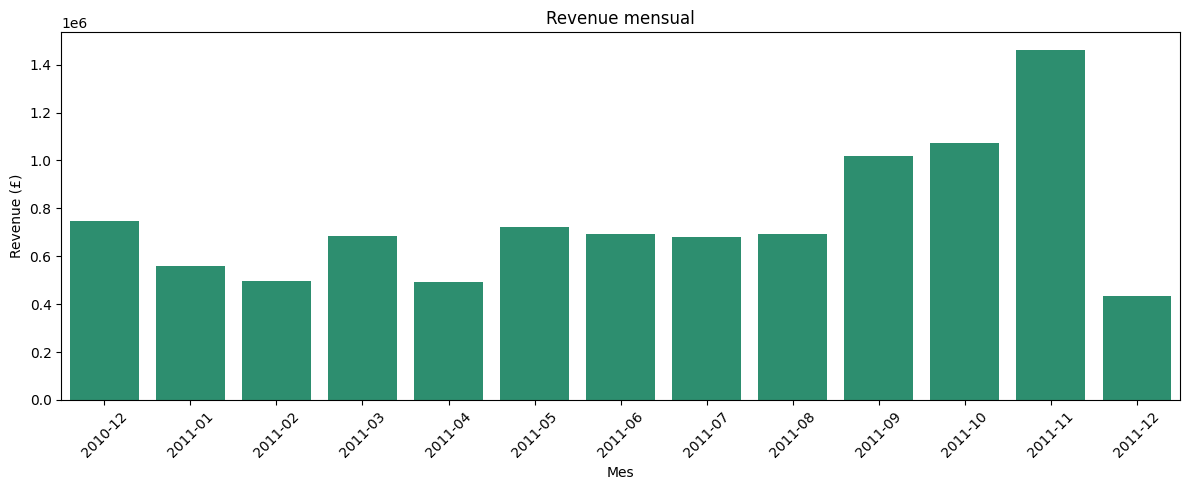

In [13]:
fct_orders['invoiced_date'] = pd.to_datetime(fct_orders['invoiced_date'])
monthly = (
    fct_orders[fct_orders['is_cancelled']==0]
    .groupby(fct_orders['invoiced_date'].dt.to_period('M'))['revenue']
    .sum()
    .reset_index()
    
)
monthly['invoiced_date'] = monthly['invoiced_date'].astype(str)

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly, x='invoiced_date', y='revenue', color='#1D9E75')
plt.title('Revenue mensual')
plt.xlabel('Mes')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/screenshots/revenue_mensual.png', dpi=150)
plt.show()



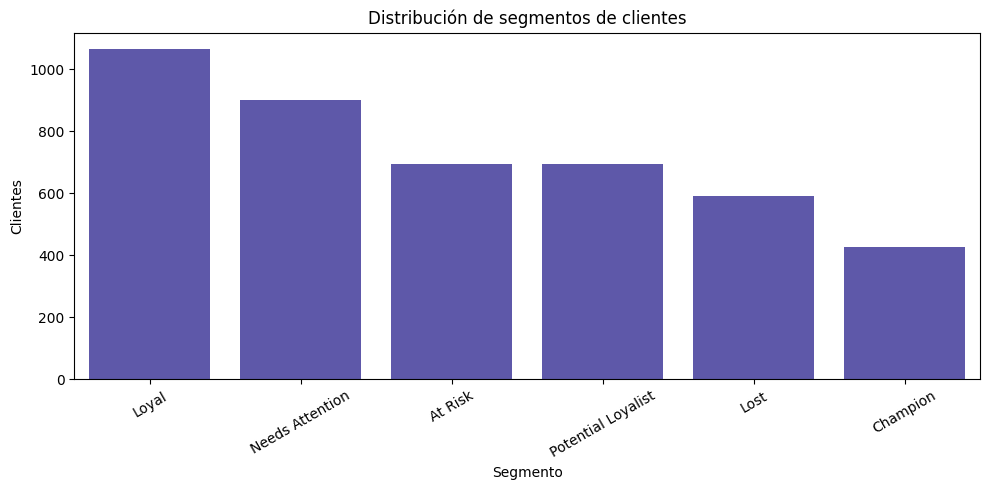

In [14]:
segment_counts = dim_customers['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['segment', 'count']

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_counts, x='segment', y='count', color='#534AB7')
plt.title('Distribución de segmentos de clientes')
plt.xlabel('Segmento')
plt.ylabel('Clientes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../dashboard/screenshots/rfm_segments.png', dpi=150)
plt.show()

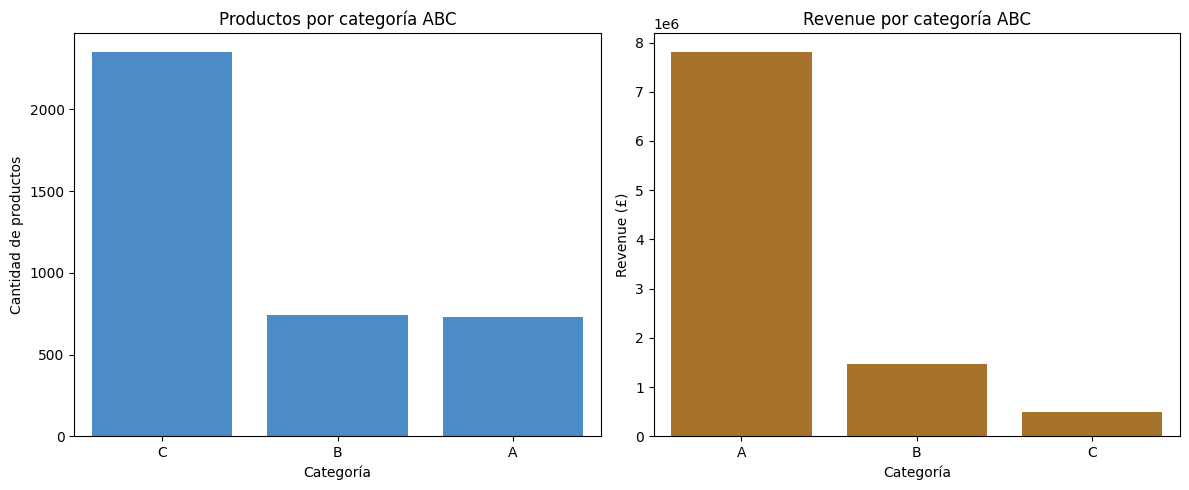

In [15]:
abc_counts = dim_products['abc_category'].value_counts().reset_index()
abc_counts.columns = ['category', 'count']
abc_revenue = dim_products.groupby('abc_category')['total_revenue'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=abc_counts, x='category', y='count', color='#378ADD', ax=axes[0])
axes[0].set_title('Productos por categoría ABC')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Cantidad de productos')

sns.barplot(data=abc_revenue, x='abc_category', y='total_revenue', color='#BA7517', ax=axes[1])
axes[1].set_title('Revenue por categoría ABC')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('../dashboard/screenshots/abc_analysis.png', dpi=150)
plt.show()